# KNN Method Demonstration in Python
#### Credit Scoring Problem (Using Bank Loan KNN Data)

## **Objective:** Build and evaluate a *k-Nearest Neighbours (KNN)* classification model to predict whether a loan applicant is likely to **default** using a real bank loan dataset.

## 1. Background
Credit scoring is a fundamental problem in **retail banking** and **consumer finance**. Banks need to assess the **creditworthiness** of applicants before approving loans, credit cards, or overdraft limits.

Typical business questions include:
- What is the probability that an applicant will **default** on a loan?
- Which characteristics (employment, existing debt, address stability, etc.) are associated with higher risk?

In this notebook, we:
1. Load a bank loan dataset containing information about applicants and whether they defaulted.
2. Perform basic **exploratory data analysis (EDA)**.
3. Split the data into **training** and **test** sets.
4. Apply **feature scaling**.
5. Fit a **KNN classifier**.
6. Tune the number of neighbours (**k**) using simple model comparison.
7. Evaluate the model using a **confusion matrix**, **classification report**, and **ROC–AUC**.

## 2. Data Description
We work with a bank loan dataset where each row corresponds to one **loan applicant**.

| Variable   | Type      | Description                                                   |
|------------|-----------|---------------------------------------------------------------|
| `SN`       | Integer   | Serial number / ID of the applicant (identification only)    |
| `AGE`      | Numeric   | Age band of the applicant (coded categories 1–6)             |
| `EMPLOY`   | Numeric   | Years of employment (or employment band)                      |
| `ADDRESS`  | Numeric   | Years at current address / stability of residence             |
| `DEBTINC`  | Numeric   | Debt-to-income ratio (%)                                      |
| `CREDDEBT` | Numeric   | Credit card debt                                              |
| `OTHDEBT`  | Numeric   | Other debts                                                   |
| `DEFAULTER`| Binary    | Target variable: 1 = default, 0 = non-default                |

We will drop 'SN' and 'AGE' . The variable age is removed because it's a categorical variable and not suitable for Euclidean distance.

## 3. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

plt.rcParams['figure.figsize'] = (6, 4)
np.random.seed(42)

## 4. Load and Inspect the Dataset

In [2]:
# Load the attached CSV file
file_path = 'BANK LOAN KNN.csv'  # adjust path if needed
df = pd.read_csv(file_path)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (389, 8)


,SN,AGE,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER
0,1,3,17,12,9.3,11.36,5.01,1
1,5,1,2,0,17.3,1.79,3.06,1
2,8,3,12,11,3.6,0.13,1.24,0
3,9,1,3,4,24.4,1.36,3.28,1
4,13,3,24,14,10.0,3.93,2.47,0


### 4.1 Basic Summary Statistics

In [3]:
df.describe(include='all')

,SN,AGE,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER
count,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000
mean,361.655527,1.863753,7.172237,7.871465,11.440360,1.718046,3.152699,0.470437
std,203.863545,0.756039,6.276995,6.640933,7.427463,2.486684,3.605031,0.499768
min,1.000000,1.000000,0.000000,0.000000,0.900000,0.020000,0.130000,0.000000
25%,178.000000,1.000000,2.000000,3.000000,5.800000,0.380000,1.060000,0.000000
50%,368.000000,2.000000,6.000000,6.000000,9.700000,0.930000,1.940000,0.000000
75%,539.000000,2.000000,11.000000,11.000000,15.200000,1.980000,3.820000,1.000000
max,700.000000,3.000000,31.000000,31.000000,41.300000,20.560000,27.030000,1.000000


### 4.2 Target Variable Distribution

In [4]:
df['DEFAULTER'].value_counts(normalize=True) * 100

DEFAULTER
0    52.956298
1    47.043702
Name: proportion, dtype: float64

## 5. Train–Test Split

In [5]:
# Separate features (X) and target (y)
X = df.drop(['DEFAULTER', 'AGE','SN'], axis=1)
y = df['DEFAULTER']

# 70% training, 30% test; stratified to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((272, 5), (117, 5))

## 6. Feature Scaling
KNN is a **distance-based** method (typically Euclidean distance). If features are on different scales,
variables with large ranges (e.g., `CREDDEBT`) would dominate the distance calculation.
We therefore standardize all predictor variables to have mean 0 and standard deviation 1.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[ 0.84762196, -0.75871316,  1.1098582 ,  0.39061782,  0.41626206],
       [ 0.22702123,  1.49423422, -0.00388993,  0.08751828,  0.11072931],
       [ 0.53732159, -0.30812369, -0.89488843, -0.56142562, -0.59942788],
       [-0.39357951, -0.75871316, -0.31017067,  0.06808882, -0.227834  ],
       [-0.70387988,  1.64443071,  0.48337488, -0.37490282, -0.17278306]])

## 7. Baseline KNN Classifier (Fixed k)

In [7]:
# Start with a baseline model using k = square root of n
k_baseline = int(np.sqrt(len(X_train)))
knn_baseline = KNeighborsClassifier(n_neighbors=k_baseline)
knn_baseline.fit(X_train_scaled, y_train)

y_test_pred = knn_baseline.predict(X_test_scaled) # Predicting y values for test data

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, digits=3))

Confusion Matrix:
[[52 10]
 [23 32]]

Classification Report:

              precision    recall  f1-score   support

           0      0.693     0.839     0.759        62
           1      0.762     0.582     0.660        55

    accuracy                          0.718       117
   macro avg      0.728     0.710     0.709       117
weighted avg      0.726     0.718     0.712       117



## 8. Choosing the Number of Neighbours (k)
The choice of **k** controls the complexity of the KNN model.
- Small k (e.g., 1–3): low bias, high variance; model may overfit.
- Large k: smoother decision boundary, but risk of underfitting.

The general recommendation is K = sqrt(n). However, it is recommended to evaluate the solution for range of **k values**


In [8]:
k_values = list(range(10, 20))
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    test_accuracies.append(knn.score(X_test_scaled, y_test))

best_k = k_values[int(np.argmax(test_accuracies))]
best_k, max(test_accuracies)

(15, 0.7350427350427351)

### 8.1 Plot Test Accuracy vs k

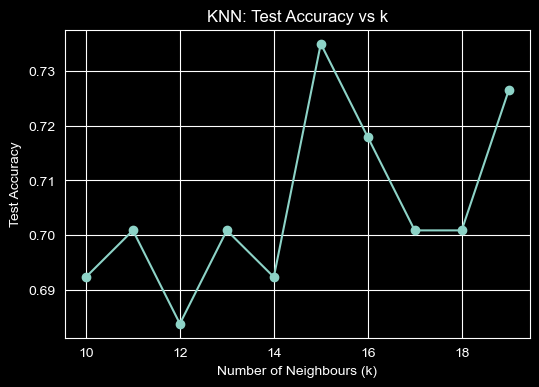

In [9]:
plt.figure()
plt.plot(k_values, test_accuracies, marker='o')
plt.xlabel('Number of Neighbours (k)')
plt.ylabel('Test Accuracy')
plt.title('KNN: Test Accuracy vs k')
plt.grid(True)
plt.show()

## 9. Final KNN Model and Evaluation
We now re-fit the KNN classifier using the **best k** chosen from the previous step and examine the confusion matrix and classification report.

In [10]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
print("Best k:", best_k)
print("\nConfusion Matrix (final model):\n", cm)
print("\nClassification Report (final model):\n")
print(classification_report(y_test, y_pred, digits=3))

Best k: 15

Confusion Matrix (final model):
 [[52 10]
 [21 34]]

Classification Report (final model):

              precision    recall  f1-score   support

           0      0.712     0.839     0.770        62
           1      0.773     0.618     0.687        55

    accuracy                          0.735       117
   macro avg      0.743     0.728     0.729       117
weighted avg      0.741     0.735     0.731       117



### 9.1 Visualizing the Confusion Matrix

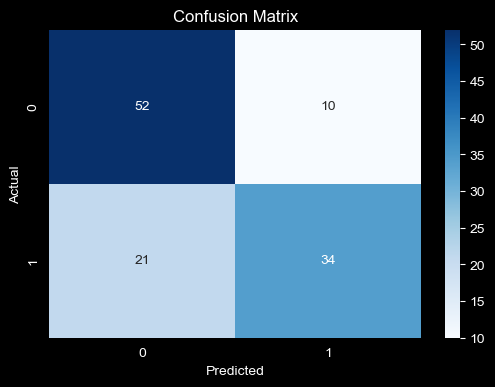

In [11]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## 10. ROC Curve and AUC
The **Receiver Operating Characteristic (ROC)** curve shows the trade-off between **True Positive Rate (TPR)** and **False Positive Rate (FPR)**
for different classification thresholds. The **Area Under the Curve (AUC)** summarizes this trade-off into a single number (1.0 = perfect classifier, 0.5 = random guessing).

ROC–AUC: 0.82


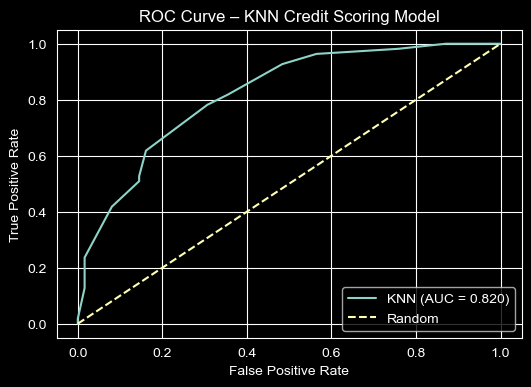

In [12]:
# Obtain predicted probabilities for the positive class (default = 1)
y_proba = knn_final.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

print("ROC–AUC:", round(auc, 3))

plt.figure()
plt.plot(fpr, tpr, label=f'KNN (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – KNN Credit Scoring Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Inference :
The ROC-AUC for test data is 0.82. Therefore, KNN method is performing well for predicting customer default.